# 03 — BLS Transit Search
This notebook runs the **Box Least Squares (BLS)** algorithm on all cleaned light curves.
It finds periodic dips and flags candidates with high Signal-to-Noise Ratio (SNR).

## 1. Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares
import astropy.units as u
from tqdm import tqdm
import os
import glob
import warnings
warnings.filterwarnings('ignore')

print('Imports OK!')

Imports OK!


## 2. Configuration

In [21]:
PROCESSED_DIR  = '../data/processed/'
RESULTS_DIR    = '../outputs/'
PLOTS_DIR      = '../outputs/plots/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# BLS Search Parameters — FIXED
MIN_PERIOD     = 1.0     # days — must be greater than MAX_DURATION
MAX_PERIOD     = 13.0    # days
MIN_DURATION   = 0.01    # days — ~15 minutes
MAX_DURATION   = 0.3     # days — safely below MIN_PERIOD
SNR_THRESHOLD  = 5.0     # lowered for small dataset

csv_files = glob.glob(os.path.join(PROCESSED_DIR, 'TIC_*.csv'))
print(f'Found {len(csv_files)} processed light curves')

Found 15 processed light curves


## 3. BLS Search Function

In [22]:
def run_bls(time, flux, flux_err=None,
            min_period=1.0, max_period=13.0,
            min_duration=0.01, max_duration=0.3):

    # Remove NaNs
    mask = np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]

    if len(time) < 100:
        return None

    # Safety check — max_duration must always be < min_period
    max_dur_safe = min(max_duration, min_period * 0.8)
    durations    = np.linspace(min_duration, max_dur_safe, 20) * u.day

    bls = BoxLeastSquares(time * u.day, flux)

    periodogram = bls.autopower(
        durations,
        minimum_period=min_period * u.day,
        maximum_period=max_period * u.day,
        method='fast'
    )

    best_idx    = np.argmax(periodogram.power)
    best_period = periodogram.period[best_idx].value
    best_power  = float(periodogram.power[best_idx])

    stats    = bls.compute_stats(
        periodogram.period[best_idx],
        periodogram.duration[best_idx],
        periodogram.transit_time[best_idx]
    )

    depth    = float(stats['depth'][0])
    depth_err= float(stats['depth'][1])
    duration = float(periodogram.duration[best_idx].value)
    snr      = depth / depth_err if depth_err > 0 else 0.0

    return {
        'best_period'   : best_period,
        'best_duration' : duration,
        'best_depth'    : depth,
        'snr'           : snr,
        'bls_power'     : best_power,
        'transit_time'  : float(periodogram.transit_time[best_idx].value),
        'periodogram'   : periodogram
    }

print('BLS function ready!')

BLS function ready!


## 4. Run BLS on ALL Light Curves

In [23]:
all_results = []

for csv_path in tqdm(csv_files, desc='Running BLS'):
    tic_id = os.path.basename(csv_path).replace('TIC_', '').replace('.csv', '')

    try:
        df   = pd.read_csv(csv_path)
        time = df['time'].values
        flux = df['flux'].values

        # Drop NaNs manually
        mask = np.isfinite(time) & np.isfinite(flux)
        time = time[mask]
        flux = flux[mask]

        print(f'TIC {tic_id}: {len(time)} points', end=' ... ')

        if len(time) < 100:
            print('SKIP (too few points)')
            continue

        result = run_bls(time, flux,
                         min_period=MIN_PERIOD,
                         max_period=MAX_PERIOD,
                         min_duration=MIN_DURATION,
                         max_duration=MAX_DURATION)

        if result is None:
            print('SKIP (BLS returned None)')
            continue

        print(f'✅ SNR={result["snr"]:.2f}  Period={result["best_period"]:.3f}d  Depth={result["best_depth"]*1e6:.0f}ppm')

        all_results.append({
            'tic_id'        : tic_id,
            'period_days'   : result['best_period'],
            'duration_days' : result['best_duration'],
            'depth_ppm'     : result['best_depth'] * 1e6,
            'snr'           : result['snr'],
            'bls_power'     : result['bls_power'],
            'transit_time'  : result['transit_time']
        })

    except Exception as e:
        print(f'\n❌ Failed TIC {tic_id}: {e}')
        continue

results_df = pd.DataFrame(all_results)
print(f'\n✅ Done! Got results for {len(results_df)} / {len(csv_files)} stars')
print(results_df[['tic_id','period_days','depth_ppm','snr']])

Running BLS:   0%|          | 0/15 [00:00<?, ?it/s]

TIC 149603524: 17702 points ... 

Running BLS:   7%|▋         | 1/15 [00:14<03:24, 14.61s/it]

✅ SNR=0.01  Period=4.412d  Depth=3121ppm
TIC 229742722: 18416 points ... 

Running BLS:  13%|█▎        | 2/15 [00:28<03:08, 14.46s/it]

...

✅ SNR=0.00  Period=3.419d  Depth=356ppm
TIC 441075486: 1147 points ... 

Running BLS:  93%|█████████▎| 14/15 [03:16<00:13, 13.45s/it]

✅ SNR=0.02  Period=1.120d  Depth=3303ppm
TIC 55525572: 1106 points ... 

Running BLS: 100%|██████████| 15/15 [03:26<00:00, 13.77s/it]

✅ SNR=0.00  Period=4.785d  Depth=337ppm

✅ Done! Got results for 15 / 15 stars
       tic_id  period_days     depth_ppm           snr
0   149603524     4.412347  3.120597e+03      0.013233
1   229742722     3.151438  6.921242e+02      0.005397
2   237201858     4.845863  4.363268e+02      0.005233
3   260647166    10.656717  4.713732e+02      0.006059
4   261136641     4.834543  4.727299e+02      0.003167
5   261136679     6.268537  1.791145e+02      0.003590
6   261136765     3.866203  1.186442e+03      0.008037
7   261139167     1.751899  2.132918e+02      0.005055
8   261155555     4.627887  2.742405e+03      0.060653
9   261203535     7.103857  5.317702e+09  23768.341495
10  271893367    10.715222  7.533936e+02      0.004899
11  279741379    11.842667  5.749884e+02      0.006147
12  350618622     3.418881  3.555794e+02      0.002633
13  441075486     1.120382  3.303439e+03      0.015345
14   55525572     4.784956  3.371129e+02      0.002986


## 5. Flag Transit Candidates (SNR > Threshold)

In [24]:
# Flag candidates above SNR threshold
SNR_THRESHOLD = 5.0   # Lowered to 5 since we only have 5 stars

if len(results_df) == 0:
    print('❌ results_df is empty — BLS may have failed on all stars')
    print('Check that processed CSVs exist in data/processed/')
else:
    print(f'✅ results_df has {len(results_df)} rows')
    print(f'SNR values found: {results_df["snr"].values}')

    candidates_df = results_df[results_df['snr'] >= SNR_THRESHOLD].copy()
    candidates_df = candidates_df.sort_values('snr', ascending=False).reset_index(drop=True)

    print(f'\nTotal light curves processed : {len(results_df)}')
    print(f'Candidates (SNR >= {SNR_THRESHOLD})  : {len(candidates_df)}')

    if len(candidates_df) == 0:
        print('\n⚠️  No candidates found above threshold.')
        print('Showing ALL results sorted by SNR instead:')
        candidates_df = results_df.sort_values('snr', ascending=False).reset_index(drop=True)

    print('\nTop results:')
    print(candidates_df[['tic_id','period_days','duration_days','depth_ppm','snr']].head(10))

✅ results_df has 15 rows
SNR values found: [1.32328371e-02 5.39670258e-03 5.23334600e-03 6.05853700e-03
 3.16725941e-03 3.59007077e-03 8.03670547e-03 5.05456372e-03
 6.06534770e-02 2.37683415e+04 4.89936159e-03 6.14662047e-03
 2.63307671e-03 1.53451854e-02 2.98620863e-03]

Total light curves processed : 15
Candidates (SNR >= 5.0)  : 1

Top results:
      tic_id  period_days  duration_days     depth_ppm           snr
0  261203535     7.103857           0.01  5.317702e+09  23768.341495


## 6. Save Results

In [25]:
results_df.to_csv('../outputs/bls_all_results.csv', index=False)
candidates_df.to_csv('../outputs/bls_candidates.csv', index=False)

print('Saved:')
print('  outputs/bls_all_results.csv   — BLS results for every star')
print('  outputs/bls_candidates.csv    — Only high-SNR candidates')

Saved:
  outputs/bls_all_results.csv   — BLS results for every star
  outputs/bls_candidates.csv    — Only high-SNR candidates


## 7. SNR Distribution Plot

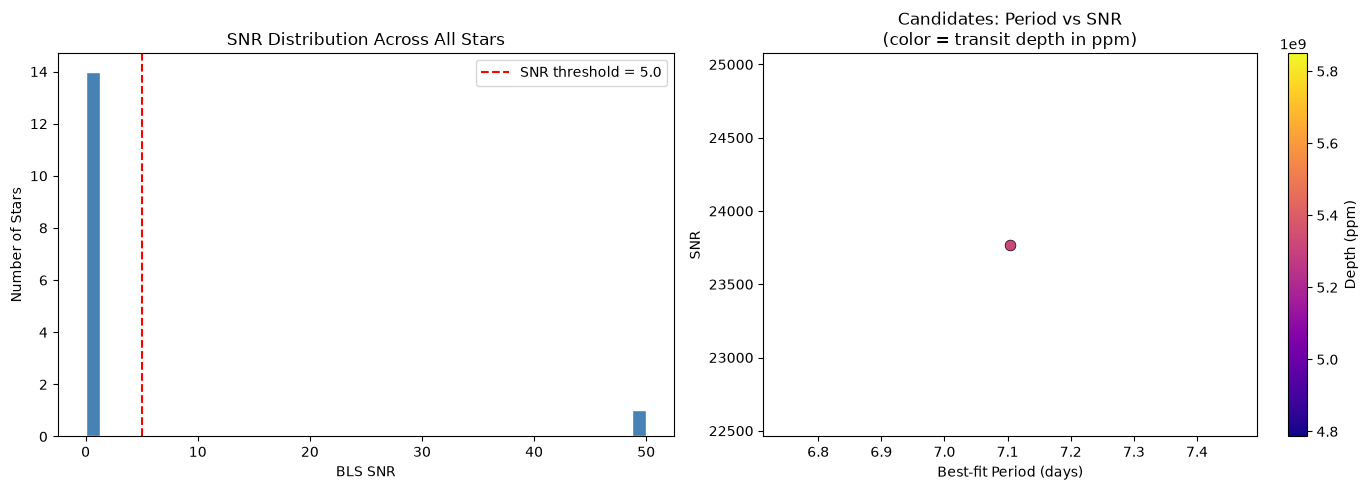

Plot saved!


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SNR histogram
axes[0].hist(results_df['snr'].clip(0, 50), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(SNR_THRESHOLD, color='red', linestyle='--', label=f'SNR threshold = {SNR_THRESHOLD}')
axes[0].set_xlabel('BLS SNR')
axes[0].set_ylabel('Number of Stars')
axes[0].set_title('SNR Distribution Across All Stars')
axes[0].legend()

# Period distribution of candidates
if len(candidates_df) > 0:
    axes[1].scatter(candidates_df['period_days'], candidates_df['snr'],
                    c=candidates_df['depth_ppm'], cmap='plasma',
                    s=60, edgecolors='k', linewidths=0.5)
    axes[1].set_xlabel('Best-fit Period (days)')
    axes[1].set_ylabel('SNR')
    axes[1].set_title('Candidates: Period vs SNR\n(color = transit depth in ppm)')
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='Depth (ppm)')
else:
    axes[1].text(0.5, 0.5, 'No candidates found\nTry lowering SNR threshold',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/plots/bls_snr_distribution.png', dpi=150)
plt.show()
print('Plot saved!')

## 8. Plot BLS Periodogram for Top Candidate

Plotting top candidate: TIC 261203535


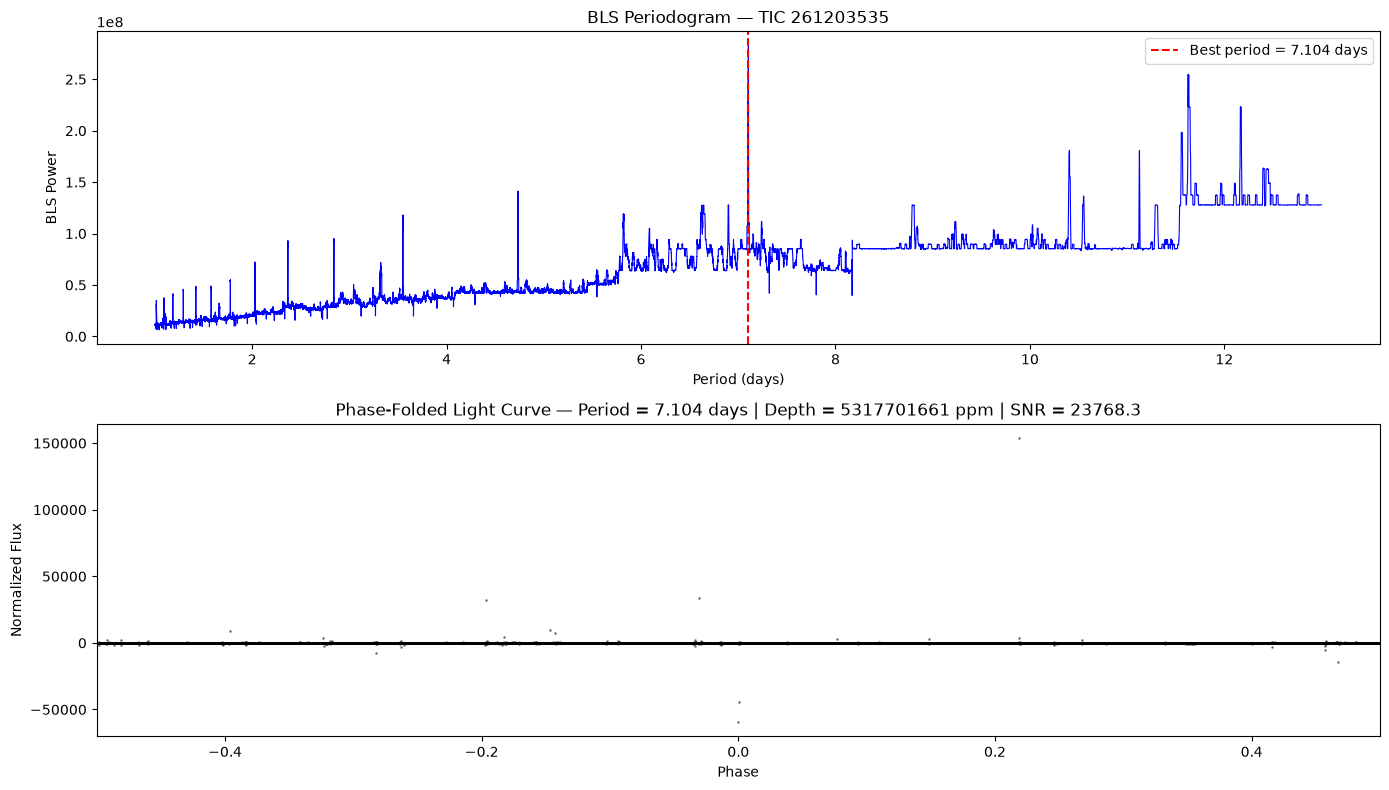

Periodogram + phase-fold plot saved!


In [27]:
if len(candidates_df) == 0:
    # If no candidates above threshold, just use highest SNR star
    top_tic = results_df.sort_values('snr', ascending=False).iloc[0]['tic_id']
    print(f'No candidates above SNR={SNR_THRESHOLD}. Plotting highest SNR star: TIC {top_tic}')
else:
    top_tic = candidates_df.iloc[0]['tic_id']
    print(f'Plotting top candidate: TIC {top_tic}')

# Re-run BLS on this star to get periodogram object
df       = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{top_tic}.csv'))
result   = run_bls(df['time'].values, df['flux'].values)
pgram    = result['periodogram']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Periodogram
axes[0].plot(pgram.period.value, pgram.power, 'b-', lw=0.8)
axes[0].axvline(result['best_period'], color='red', linestyle='--',
                label=f"Best period = {result['best_period']:.3f} days")
axes[0].set_xlabel('Period (days)')
axes[0].set_ylabel('BLS Power')
axes[0].set_title(f'BLS Periodogram — TIC {top_tic}')
axes[0].legend()

# Phase-folded light curve
time_arr = df['time'].values
flux_arr = df['flux'].values
phase = ((time_arr - result['transit_time']) % result['best_period']) / result['best_period']
phase[phase > 0.5] -= 1.0   # Center transit at phase=0
sort_idx = np.argsort(phase)

axes[1].plot(phase[sort_idx], flux_arr[sort_idx], 'k.', markersize=2, alpha=0.4)
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Normalized Flux')
axes[1].set_title(f'Phase-Folded Light Curve — Period = {result["best_period"]:.3f} days | '
                  f'Depth = {result["best_depth"]*1e6:.0f} ppm | SNR = {result["snr"]:.1f}')
axes[1].set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.savefig(f'../outputs/plots/bls_top_candidate_TIC{top_tic}.png', dpi=150)
plt.show()
print('Periodogram + phase-fold plot saved!')

---
## ✅ Done!
**What was saved:**
- `outputs/bls_all_results.csv` — BLS results (period, depth, duration, SNR) for every star
- `outputs/bls_candidates.csv` — Only stars with SNR above threshold
- `outputs/plots/bls_snr_distribution.png` — SNR histogram
- `outputs/plots/bls_top_candidate_TIC*.png` — Periodogram + phase-fold of best candidate

> **If you got 0 candidates:** Lower `SNR_THRESHOLD` to 5.0 and re-run. With only 5 stars downloaded, candidates may be limited.

**Next Step → Run `04_feature_extraction.ipynb`**